In [99]:
import numpy as np
import warnings
import xarray as xr
from dask.array.core import PerformanceWarning
from dask.diagnostics import ProgressBar
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.patches import Rectangle
from pyproj import Transformer
import jupyter_bokeh

import rioxarray as rxr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

from pystac_client import Client as pystac_client
from odc.stac import stac_load

warnings.filterwarnings("ignore", message="In a future version of xarray the default value for join.*", category=FutureWarning)
warnings.filterwarnings("ignore", message="Increasing number of chunks.*", category=PerformanceWarning)

from shapely.geometry import mapping, box, shape


# Approximate EPSG:3031 location for the Amundsen Sea sector / Thwaites-Pine Island area.
ROI_CENTER_XY_M = (-2_300_000.0, 1000_000.0)
ROI_HALF_WIDTH_CELLS = 1500
CUBE_RES_M = 100

cx, cy = ROI_CENTER_XY_M
half = ROI_HALF_WIDTH_CELLS * CUBE_RES_M


antarctic_crs = ccrs.SouthPolarStereo(
    central_longitude=0,
    true_scale_latitude=-71,
)

In [100]:
to_lonlat = Transformer.from_crs("EPSG:3031", "EPSG:4326", always_xy=True)

corners_3031 = [
    (cx - half, cy - half),
    (cx - half, cy + half),
    (cx + half, cy - half),
    (cx + half, cy + half),
]

corners_lonlat = [to_lonlat.transform(x, y) for x, y in corners_3031]

bbox = [
    min(lon for lon, lat in corners_lonlat),
    min(lat for lon, lat in corners_lonlat),
    max(lon for lon, lat in corners_lonlat),
    max(lat for lon, lat in corners_lonlat),
]

bbox

[-70.86635679409451,
 -68.95219601061162,
 -61.85839876773828,
 -65.45764355045239]

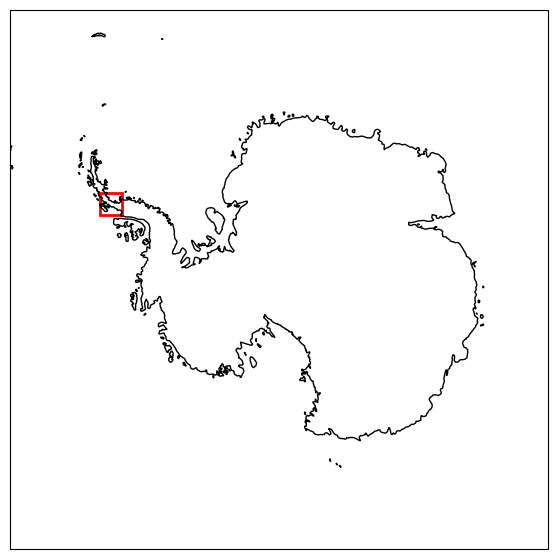

In [101]:
# Convert ROI center from meters to the appropriate scale and calculate half-width
cx, cy = ROI_CENTER_XY_M
half = ROI_HALF_WIDTH_CELLS * 100 

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={"projection": ccrs.SouthPolarStereo()})
ax.set_extent([-180, 180, -90, -58], crs=ccrs.PlateCarree())
ax.coastlines()
ax.add_patch(Rectangle((cx - half, cy - half), 2 * half, 2 * half, fill=False, edgecolor="red", linewidth=2, transform=ax.projection))
plt.show()


In [102]:
cube_paths = [
    "https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/antarctica_cube/icetemp.zarr",
    "https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/antarctica_cube/sec.zarr",
    "https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/antarctica_cube/antarctica-combined.zarr",
    "https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/antarctica_cube/icemask_composite.zarr/",
    "https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/antarctica_cube/ice_velocity.zarr",
]

ds = xr.open_mfdataset(cube_paths, engine="zarr", chunks={}, compat="no_conflicts")

x_index = int(np.abs(ds["x"].values - ROI_CENTER_XY_M[0]).argmin())
y_index = int(np.abs(ds["y"].values - ROI_CENTER_XY_M[1]).argmin())
x_slice = slice(x_index - ROI_HALF_WIDTH_CELLS, x_index + ROI_HALF_WIDTH_CELLS + 1)
y_slice = slice(y_index - ROI_HALF_WIDTH_CELLS, y_index + ROI_HALF_WIDTH_CELLS + 1)

ds = ds.isel(x=x_slice, y=y_slice).chunk({"x": -1, "y": -1})

ds


<xarray.Dataset> Size: 22GB
Dimensions:                                       (y: 3001, x: 3001, depth: 91,
                                                   time_period: 27, time: 48)
Coordinates:
  * y                                             (y) float32 12kB 8.5e+05 .....
  * x                                             (x) float32 12kB -2.45e+06 ...
  * depth                                         (depth) int16 182B 0 ... 4500
  * time_period                                   (time_period) int64 216B 0 ...
  * time                                          (time) datetime64[ns] 384B ...
    spatial_ref                                   int64 8B 0
Data variables: (12/40)
    englacial_temp_profile_quality_flag           (y, x) float16 18MB dask.array<chunksize=(3001, 3001), meta=np.ndarray>
    englacial_temp_profile_tice                   (depth, y, x) float16 2GB dask.array<chunksize=(1, 3001, 3001), meta=np.ndarray>
    surface_elevation_change_basin_id             (y, x) float32 36MB dask.array<chunksize=(3001, 3001), meta=np.ndarray>
    surface_elevation_change_cell_end_times       (time_period, y, x) float32 973MB dask.array<chunksize=(1, 3001, 3001), meta=np.ndarray>
    surface_elevation_change_cell_start_times     (time_period, y, x) float32 973MB dask.array<chunksize=(1, 3001, 3001), meta=np.ndarray>
    surface_elevation_change_end_time             (time_period) float32 108B dask.array<chunksize=(1,), meta=np.ndarray>
    ...                                            ...
    ice_sheet_surface_velocity_easting_stddev     (time, y, x) float32 2GB dask.array<chunksize=(1, 3001, 3001), meta=np.ndarray>
    ice_sheet_surface_velocity_magnitude          (time, y, x) float32 2GB dask.array<chunksize=(1, 3001, 3001), meta=np.ndarray>
    ice_sheet_surface_velocity_measurement_count  (time, y, x) float32 2GB dask.array<chunksize=(1, 3001, 3001), meta=np.ndarray>
    ice_sheet_surface_velocity_northing           (time, y, x) float32 2GB dask.array<chunksize=(1, 3001, 3001), meta=np.ndarray>
    ice_sheet_surface_velocity_northing_stddev    (time, y, x) float32 2GB dask.array<chunksize=(1, 3001, 3001), meta=np.ndarray>
    ice_sheet_surface_velocity_vertical           (time, y, x) float32 2GB dask.array<chunksize=(1, 3001, 3001), meta=np.ndarray>

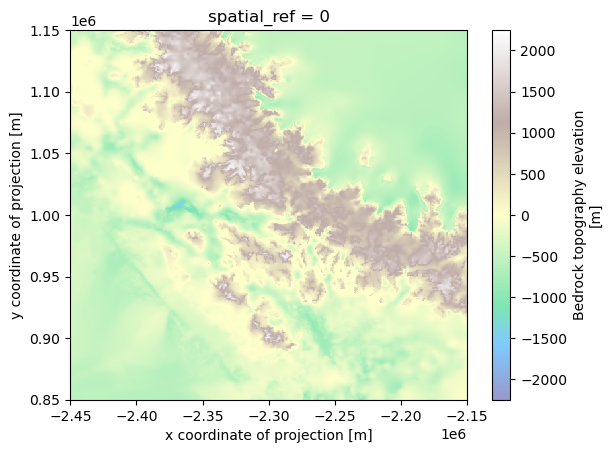

In [146]:
bed = ds.bedrock_topography_bed
bed_overlay = bed.where(bed.notnull() & (bed != 0))

bed_overlay.plot(
    x="x",
    y="y",
    cmap="terrain",
    alpha=0.5,
    add_colorbar=True,
)


## Sentinel-2 Data Archives Access Example

In [124]:
catalog = pystac_client.open("https://earth-search.aws.element84.com/v1")
chunk={} # <-- use dask
res=100 # 100m resolution

query1 = catalog.search(
    collections=["sentinel-2-l2a"], datetime="2021-03-01/2021-03-30", limit=100, # sentinel-2-pre-c1-l2a
    bbox=bbox, query={"eo:cloud_cover": {"lt": 50}}
)

items = list(query1.items())
len(items)

84

In [125]:
from IPython.display import Image, display
import ipywidgets as widgets

def show(i):
    item = items[i]
    print(i, item.id, item.properties.get("eo:cloud_cover"))
    display(Image(url=item.assets["thumbnail"].href, width=600))

widgets.interact(
    show,
    i=widgets.IntSlider(0, 0, len(items) - 1, continuous_update=False),
)

interactive(children=(IntSlider(value=0, continuous_update=False, description='i', max=83), Output()), _dom_cl…

<function __main__.show(i)>

In [126]:
sen2_ds = stac_load(
    items,
    bands=("red", "green", "blue", 'scl'),
    crs="EPSG:3031",        # important: one common Antarctic grid
    resolution=100,
    bbox=bbox,
    chunks={},
    groupby="solar_day",
)

with ProgressBar():
    sen2_ds = sen2_ds.load()

sen2_ds

[########################################] | 100% Completed | 94.43 ss


<xarray.Dataset> Size: 3GB
Dimensions:      (y: 5189, x: 5184, time: 15)
Coordinates:
  * y            (y) float64 42kB 1.277e+06 1.276e+06 ... 7.578e+05 7.578e+05
  * x            (x) float64 41kB -2.557e+06 -2.557e+06 ... -2.039e+06
  * time         (time) datetime64[ns] 120B 2021-03-03T13:50:48.462000 ... 20...
    spatial_ref  int32 4B 3031
Data variables:
    red          (time, y, x) uint16 807MB 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0
    green        (time, y, x) uint16 807MB 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0
    blue         (time, y, x) uint16 807MB 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0
    scl          (time, y, x) uint8 403MB 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0

In [ ]:
bad_scl = [0, 1, 3, 7, 8, 10]
# keep 11 = snow/ice ; leave 9 as well

clear = ~sen2_ds["scl"].isin(bad_scl)
clear_fraction = clear.mean(("x", "y")).compute()
clear_fraction.to_series().sort_values(ascending=False).head(10)


best_to_worst = clear_fraction.sortby(clear_fraction, ascending=False)["time"]

rgb_clear = sen2_ds[["red", "green", "blue"]].where(clear)
rgb_sorted = rgb_clear.sel(time=best_to_worst)

with ProgressBar():
    rgb_mosaic = rgb_sorted.bfill("time").isel(time=0).compute()

rgb_mosaic = rgb_mosaic.rio.reproject_match(ds)

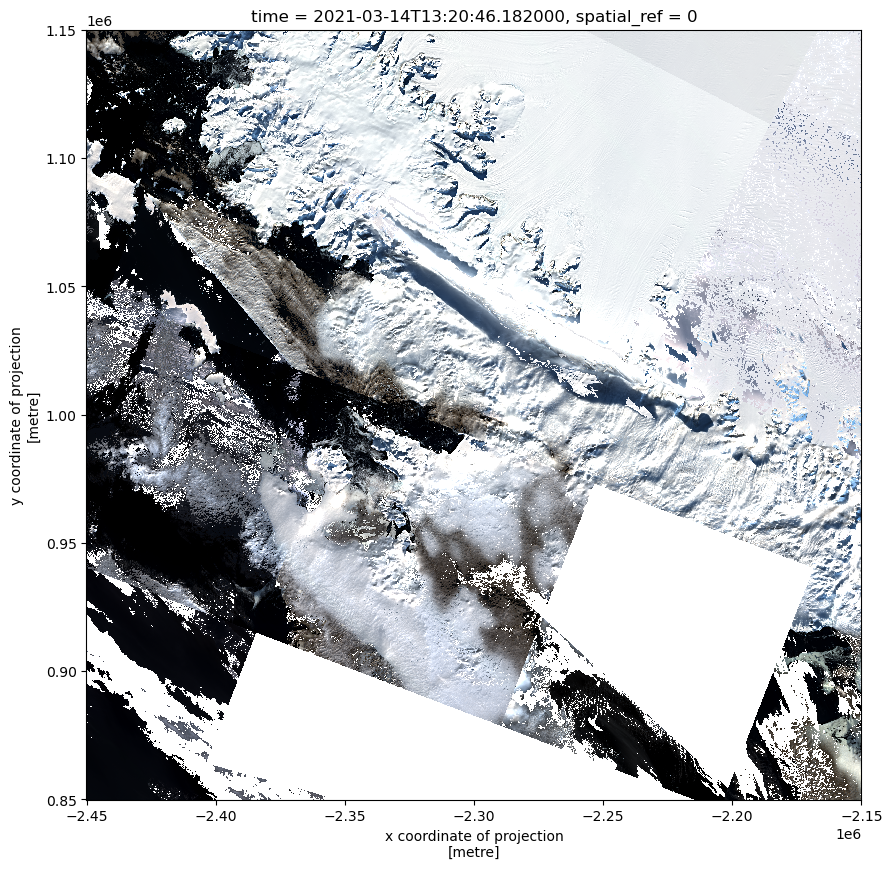

In [ ]:
rgb_da = rgb_mosaic.to_array("band")

rgb_da.plot.imshow(
    x="x",
    y="y",
    rgb="band",
    vmin=0,
    vmax=10000,
    figsize=(10, 10),
)

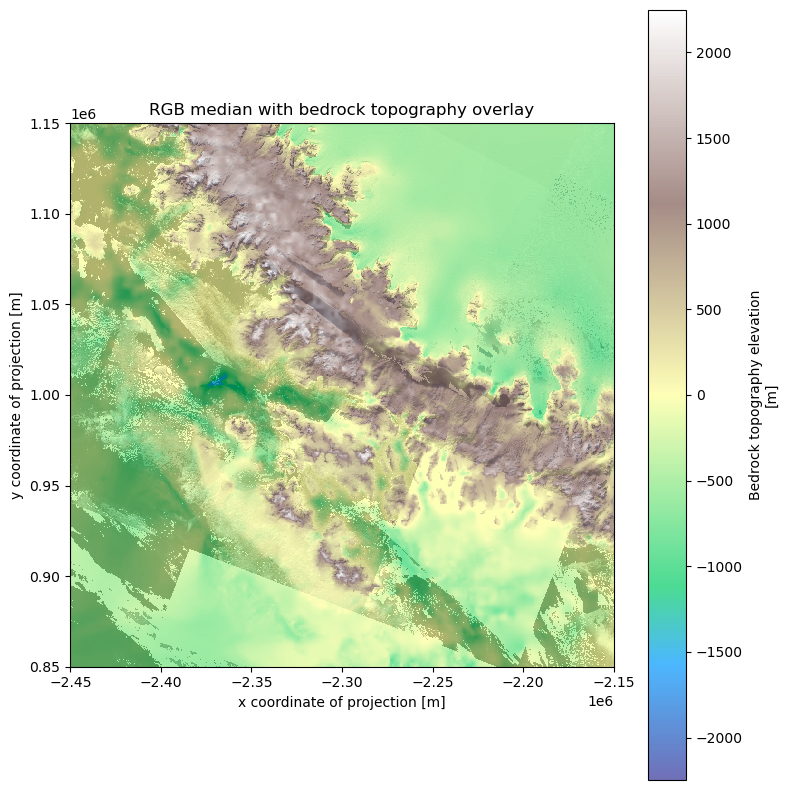

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))
rgb_da.plot.imshow(
    x="x",
    y="y",
    rgb="band",
    vmin=0,
    vmax=10000,
    ax=ax,
    add_colorbar=False,
)

bed_overlay.plot(
    x="x",
    y="y",
    ax=ax,
    cmap="terrain",
    alpha=0.7,
    add_colorbar=True,
)

ax.set_title("RGB median with bedrock topography overlay")
ax.set_aspect("equal")

plt.tight_layout()
plt.show()